In [1]:
# C:\ManzaRotation\Analysis\03_basic_glm.py

from pathlib import Path
from datetime import datetime
import json
import pandas as pd
from nilearn.glm.first_level import FirstLevelModel
import shutil

Build file paths, only need to change the subject ID 

In [2]:
subject = "sub-097"

project_dir = Path(r"C:\ManzaRotation")

raw_dir = project_dir / "Raw"
derivatives_dir = project_dir / "Derivatives"
analysis_dir = project_dir / "Analysis"

subject_deriv_dir = derivatives_dir / subject
func_deriv_dir = subject_deriv_dir / "func"

basic_glm_dir = analysis_dir / "outputs" / subject / "basic_glm"

# Tunable analysis parameters: change these to create a new run folder.
t_r = 2.0
smoothing_fwhm = 6.0
basic_confounds = [
    "trans_x", "trans_y", "trans_z",
    "rot_x", "rot_y", "rot_z"
    
]
mask1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-brain_mask.nii.gz"
mask_img = mask1_path

run_stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
run_label = f"tR-{t_r:g}s__smooth-{smoothing_fwhm:g}mm__conf-{len(basic_confounds)}__mask-brain"
run_id = f"{run_stamp}__{run_label}"

run_dir = basic_glm_dir / "runs" / run_id
design_matrices_dir = run_dir / "design_matrices"
maps_dir = run_dir / "maps"
figures_dir = run_dir / "figures"
provenance_dir = run_dir / "provenance"

for folder in [design_matrices_dir, maps_dir, figures_dir, provenance_dir]:
    folder.mkdir(parents=True, exist_ok=True)

modulate1_path = func_deriv_dir / f"{subject}_task-modulate1_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"
modulate2_path = func_deriv_dir / f"{subject}_task-modulate2_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"

events1_path = basic_glm_dir / f"{subject}_task-modulate1_events-feelOnly.tsv"
events2_path = basic_glm_dir / f"{subject}_task-modulate2_events-feelOnly.tsv"

confounds1_path = func_deriv_dir / f"{subject}_task-modulate1_desc-confounds_timeseries.tsv"
confounds2_path = func_deriv_dir / f"{subject}_task-modulate2_desc-confounds_timeseries.tsv"

In [3]:
analysis_params = {
    "subject": subject,
    "t_r": t_r,
    "smoothing_fwhm": smoothing_fwhm,
    "mask_img": str(mask_img),
    "basic_confounds": basic_confounds,
    "run_id": run_id,
    "run_dir": str(run_dir),
}

inputs_manifest = pd.DataFrame(
    [
        {"kind": "bold", "run": "modulate1", "path": str(modulate1_path)},
        {"kind": "bold", "run": "modulate2", "path": str(modulate2_path)},
        {"kind": "events", "run": "modulate1", "path": str(events1_path)},
        {"kind": "events", "run": "modulate2", "path": str(events2_path)},
        {"kind": "confounds", "run": "modulate1", "path": str(confounds1_path)},
        {"kind": "confounds", "run": "modulate2", "path": str(confounds2_path)},
        {"kind": "mask", "run": "modulate1", "path": str(mask1_path)},
    ]
)

with open(provenance_dir / "params.json", "w", encoding="utf-8") as f:
    json.dump(analysis_params, f, indent=2)

inputs_manifest.to_csv(provenance_dir / "inputs.tsv", sep="\t", index=False)

print("Run folder:", run_dir)
print("Provenance folder:", provenance_dir)

Run folder: C:\ManzaRotation\Analysis\outputs\sub-097\basic_glm\runs\20260612-125915__tR-2s__smooth-6mm__conf-6__mask-brain
Provenance folder: C:\ManzaRotation\Analysis\outputs\sub-097\basic_glm\runs\20260612-125915__tR-2s__smooth-6mm__conf-6__mask-brain\provenance


next load the events and confounds into pandas tables

In [4]:
events1 = pd.read_csv(events1_path, sep="\t")
events2 = pd.read_csv(events2_path, sep="\t")
confounds1_full = pd.read_csv(confounds1_path, sep="\t")
confounds2_full = pd.read_csv(confounds2_path, sep="\t")

In [5]:
print("Events 1 shape:", events1.shape)
print("Events 2 shape:", events2.shape)
print("Confounds 1 shape:", confounds1_full.shape)
print("Confounds 2 shape:", confounds2_full.shape)  

Events 1 shape: (32, 3)
Events 2 shape: (32, 3)
Confounds 1 shape: (310, 253)
Confounds 2 shape: (310, 260)


In [6]:
print("Run 1 trial counts:")
print(events1["trial_type"].value_counts())
print("Run 2 trial counts:")
print(events2["trial_type"].value_counts()) 

Run 1 trial counts:
trial_type
positive_arousal    8
negative_valence    8
positive_valence    8
negative_arousal    8
Name: count, dtype: int64
Run 2 trial counts:
trial_type
positive_valence    8
positive_arousal    8
negative_arousal    8
negative_valence    8
Name: count, dtype: int64


In [7]:
print(confounds1_full.columns.tolist())

['global_signal', 'global_signal_derivative1', 'global_signal_derivative1_power2', 'global_signal_power2', 'csf', 'csf_derivative1', 'csf_derivative1_power2', 'csf_power2', 'white_matter', 'white_matter_derivative1', 'white_matter_power2', 'white_matter_derivative1_power2', 'csf_wm', 'tcompcor', 'std_dvars', 'dvars', 'framewise_displacement', 'rmsd', 't_comp_cor_00', 't_comp_cor_01', 't_comp_cor_02', 't_comp_cor_03', 'c_comp_cor_00', 'c_comp_cor_01', 'c_comp_cor_02', 'c_comp_cor_03', 'c_comp_cor_04', 'c_comp_cor_05', 'c_comp_cor_06', 'w_comp_cor_00', 'w_comp_cor_01', 'w_comp_cor_02', 'w_comp_cor_03', 'w_comp_cor_04', 'w_comp_cor_05', 'w_comp_cor_06', 'w_comp_cor_07', 'w_comp_cor_08', 'w_comp_cor_09', 'w_comp_cor_10', 'w_comp_cor_11', 'w_comp_cor_12', 'w_comp_cor_13', 'w_comp_cor_14', 'w_comp_cor_15', 'w_comp_cor_16', 'w_comp_cor_17', 'w_comp_cor_18', 'w_comp_cor_19', 'w_comp_cor_20', 'w_comp_cor_21', 'w_comp_cor_22', 'w_comp_cor_23', 'w_comp_cor_24', 'w_comp_cor_25', 'w_comp_cor_26', '

In [8]:
confounds1_basic = confounds1_full[basic_confounds]
confounds2_basic = confounds2_full[basic_confounds]

print("Basic confounds 1 shape:", confounds1_basic.shape)
print("Basic confounds 2 shape:", confounds2_basic.shape)

Basic confounds 1 shape: (310, 6)
Basic confounds 2 shape: (310, 6)


In [9]:
print(confounds1_basic.isna().sum())
print(confounds2_basic.isna().sum())

trans_x    0
trans_y    0
trans_z    0
rot_x      0
rot_y      0
rot_z      0
dtype: int64
trans_x    0
trans_y    0
trans_z    0
rot_x      0
rot_y      0
rot_z      0
dtype: int64


In [10]:
first_level_model = FirstLevelModel(
    t_r=t_r,
    mask_img=mask_img,
    smoothing_fwhm=smoothing_fwhm,
)

run_imgs = [modulate1_path, modulate2_path]
events = [events1, events2]
confounds = [confounds1_basic, confounds2_basic]

first_level_model = first_level_model.fit(
    run_imgs=run_imgs,
    events=events,
    confounds=confounds,
)

In [11]:
design_matrices = first_level_model.design_matrices_

print(len(design_matrices))
print("Design matrix 1 shape:", design_matrices[0].shape)
print("Design matrix 2 shape:", design_matrices[1].shape)
print(design_matrices[0].columns.tolist())
print(design_matrices[1].columns.tolist())

2
Design matrix 1 shape: (310, 23)
Design matrix 2 shape: (310, 23)
['negative_arousal', 'negative_valence', 'positive_arousal', 'positive_valence', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'constant']
['negative_arousal', 'negative_valence', 'positive_arousal', 'positive_valence', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5', 'drift_6', 'drift_7', 'drift_8', 'drift_9', 'drift_10', 'drift_11', 'drift_12', 'constant']


In [12]:
design_matrices[0].to_csv(design_matrices_dir / f"{subject}_task-modulate1_design-matrix.tsv", sep="\t")
design_matrices[1].to_csv(design_matrices_dir / f"{subject}_task-modulate2_design-matrix.tsv", sep="\t")

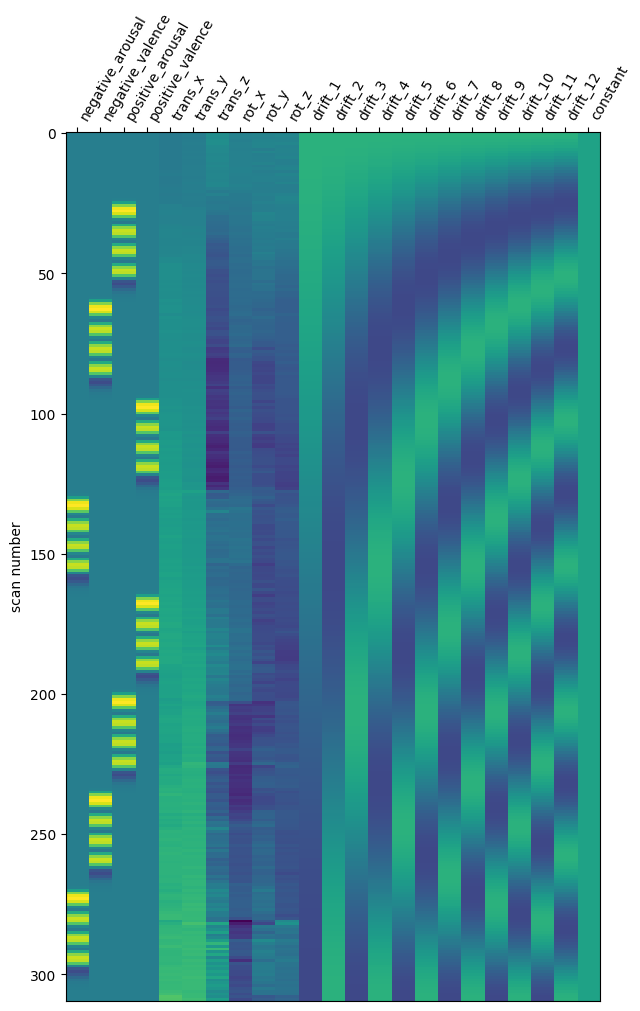

In [13]:
from nilearn.plotting import plot_design_matrix, show

plot_design_matrix(
    design_matrices[0],
    output_file=figures_dir / f"{subject}_task-modulate1_design-matrix.png",
)
plot_design_matrix(design_matrices[0])
show()

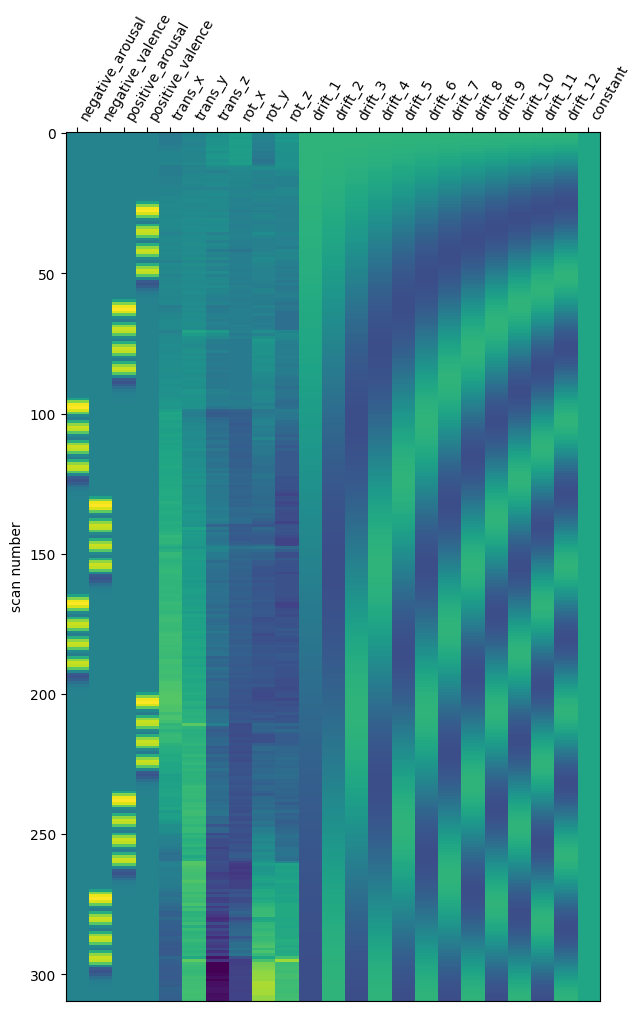

In [14]:
plot_design_matrix(
    design_matrices[1],
    output_file=figures_dir / f"{subject}_task-modulate2_design-matrix.png",
)
plot_design_matrix(design_matrices[1])
show()

C:\Users\jwhit\AppData\Local\Temp\ipykernel_13000\2689921027.py:20: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast(
C:\Users\jwhit\AppData\Local\Temp\ipykernel_13000\2689921027.py:20: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast(
C:\Users\jwhit\AppData\Local\Temp\ipykernel_13000\2689921027.py:20: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same

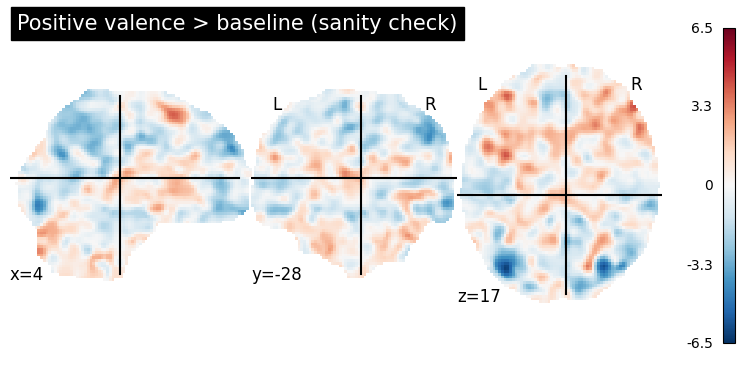

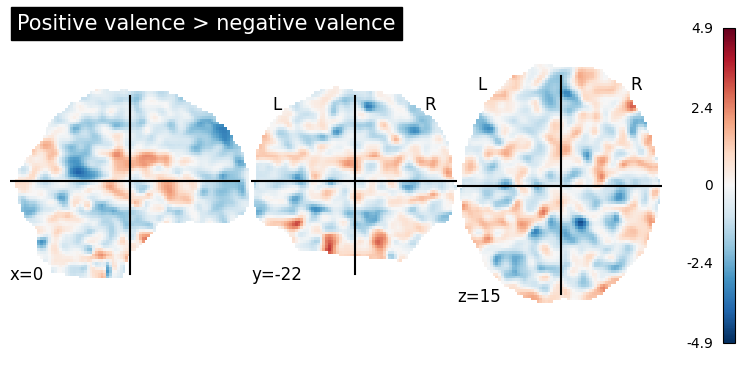

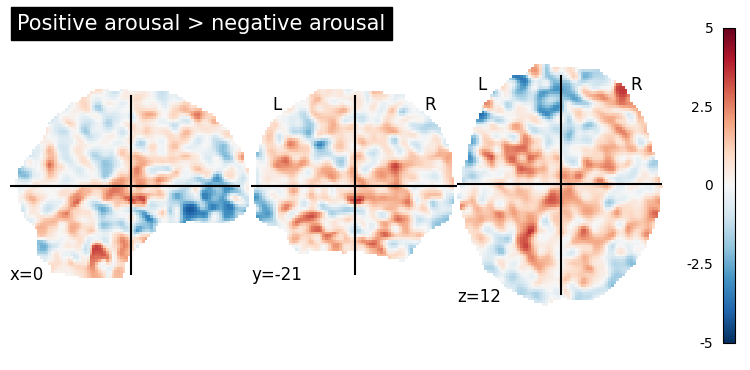

Saved contrast maps to: C:\ManzaRotation\Analysis\outputs\sub-097\basic_glm\runs\20260612-125915__tR-2s__smooth-6mm__conf-6__mask-brain\maps
Saved figures to: C:\ManzaRotation\Analysis\outputs\sub-097\basic_glm\runs\20260612-125915__tR-2s__smooth-6mm__conf-6__mask-brain\figures


In [15]:
from nilearn.plotting import plot_stat_map, show

contrast_specs = {
    "positive-valence_vs_baseline": {
        "expression": "positive_valence",
        "title": "Positive valence > baseline (sanity check)",
    },
    "positive-valence_vs_negative-valence": {
        "expression": "positive_valence - negative_valence",
        "title": "Positive valence > negative valence",
    },
    "positive-arousal_vs_negative-arousal": {
        "expression": "positive_arousal - negative_arousal",
        "title": "Positive arousal > negative arousal",
    },
}

contrast_maps = {}
for contrast_name, spec in contrast_specs.items():
    z_map = first_level_model.compute_contrast(
        spec["expression"],
        output_type="z_score",
    )
    contrast_maps[contrast_name] = z_map

    z_map.to_filename(maps_dir / f"{subject}_{contrast_name}_zmap.nii.gz")
    plot_stat_map(
        z_map,
        bg_img=None,
        title=spec["title"],
        output_file=figures_dir / f"{subject}_{contrast_name}_zmap.png",
    )

    # Also render in the notebook for quick inspection.
    plot_stat_map(z_map, bg_img=None, title=spec["title"])

show()
print("Saved contrast maps to:", maps_dir)
print("Saved figures to:", figures_dir)

In [ ]:
from nilearn.image import mean_img
import matplotlib.pyplot as plt

mean_func_1 = mean_img(modulate1_path)

plot_stat_map(
    contrast_maps["positive-valence_vs_baseline"],
    bg_img=mean_func_1,
    threshold=2.0,
    title="Positive valence > baseline (sanity check) |Z| > 2.0",
    black_bg=True,
    figure=plt.figure(figsize=(10, 4)),
    output_file=figures_dir / f"{subject}_positive-valence_vs_baseline_zmap_thresh2.png",
)
show()

In [17]:
from nilearn.image import mean_img
from nilearn.plotting import plot_stat_map, show
import matplotlib.pyplot as plt

mean_func_1 = mean_img(modulate1_path)

z_map = first_level_model.compute_contrast(
    "positive_valence - negative_valence",
    output_type="z_score",
)

plotting_config = {
    "bg_img": mean_func_1,
    "display_mode": "ortho",
    "cut_coords": (0, -22, 15),
    "black_bg": True,
}
output_path = figures_dir / f"{subject}_positive-valence_vs_negative-valence_zmap.png"

plot_stat_map(
    z_map,
    threshold=2.0,
    title="Positive valence > negative valence |Z| > 2.0",
    figure=plt.figure(figsize=(10, 4)),
    output_file=output_path,
    **plotting_config,
)
show()

C:\Users\jwhit\AppData\Local\Temp\ipykernel_13000\781002607.py:7: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  z_map = first_level_model.compute_contrast(


In [ ]:
plot_stat_map(
    contrast_maps["positive-arousal_vs_negative-arousal"],
    bg_img=mean_func_1,
    threshold=2.0,
    title="Positive arousal > negative arousal |Z| > 2.0",
    black_bg=True,
    figure=plt.figure(figsize=(10, 4)),
    output_file=figures_dir / f"{subject}_positive-arousal_vs_negative-arousal_zmap_thresh2.png",
)
show()